# Week 1 · Notebook 1 — The data, and your first tool

Welcome. Over three weeks you'll build a real algorithmic trading system: it reads
the market, forms strategies, tests them honestly, and — by week 3 — *learns* to
trade. Everything compounds; nothing you build gets thrown away.

Today is the gentlest day on purpose. Two goals:
1. Understand **the environment** — the world your strategies will live in.
2. Build your **first tool**: a price-charting function you'll reuse all week.

If your setup works and you draw a chart by the end, today succeeded.

## 1. The environment: what your strategies see

Every strategy in this program acts inside one shared world — a `DataFeed`. Think
of it as the market, frozen into a table you can query. It holds, for a whole
universe of stocks aligned to the same calendar:

- `feed.close` — closing prices, shape **(days × stocks)**
- `feed.returns` — daily returns (how much each stock moved), same shape
- `feed.volume` — how much traded

This is the single source of truth. Indicators read from it, strategies act on it,
the backtester walks through it day by day, and in week 3 the reinforcement-learning
agent will live inside it too. Learn its shape now and everything later is familiar.

In [13]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')
import numpy as np
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed

feed = DataFeed.from_dir('data/egx')
print('universe :', feed.symbols)
print('days     :', feed.n_days)
print('close is a table of shape (days, stocks):', feed.close.shape)
print()
print('last 5 closing prices of', feed.symbols[0], ':', feed.close[-5:, 0].round(2))
print('its last 5 daily returns             :', feed.returns[-5:, 0].round(4))

universe : ['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'ORAS', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'SAUD', 'SKPC', 'SUGR', 'SWDY', 'TMGH']
days     : 1159
close is a table of shape (days, stocks): (1159, 34)

last 5 closing prices of ABUK : [70.88 71.45 71.52 71.32 73.  ]
its last 5 daily returns             : [-0.0196  0.008   0.001  -0.0028  0.0236]


## 2. Your first tool — `plot_price`

You'll look at prices constantly, so build a reusable chart function. Given the
figure is already set up for you, fill in the drawing: plot the closing price, then
plot each optional overlay (like a moving average) on top.

**In:** `dates`, `close`, and an optional `overlays` dict like `{'SMA20': array}`.
**Out:** the chart's `ax` (already returned for you).
**Hint:** `ax.plot(dates, close, label='close')`, then loop over `overlays.items()`.
**Done when:** the check counts the right number of lines.

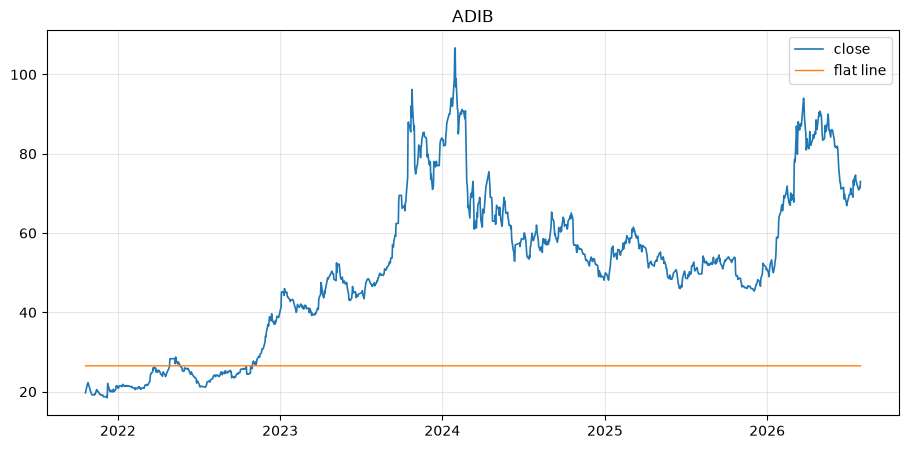

plot_price works ✓ — this is your chart tool for the whole week


In [20]:
def plot_price(dates, close, overlays=None, title='Price'):
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(dates, close, label='close', linewidth=1.2)
    for name, series in (overlays or {}).items():
        ax.plot(dates, series, label=name, linewidth=1.0)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    return ax

ax = plot_price(feed.dates, feed.close[:, 0],
                overlays={'flat line': np.full(feed.n_days, feed.close[:,1].mean())},
                title=feed.symbols[1])
assert len(ax.lines) == 2, 'expected close + 1 overlay'
plt.show()
print('plot_price works ✓ — this is your chart tool for the whole week')

## 3. What you can do this week

Now that you can see the data, here's the arc:
- **Notebook 2** — build the indicators (moving average, RSI) that turn prices into
  signals.
- **Notebook 3** — turn signals into a strategy, and write the one function at the
  heart of the whole engine.
- **Notebook 4** — backtest your strategy and **report** the result honestly against
  the benchmark.
- **Notebook 5** — put it all on a dashboard.

**Graduate** `plot_price` into `src/tradinglab/charting.py` (replace the stub), then:
`uv run pytest week1/tests/`. Tomorrow you build the indicators that go on this
chart.